In [3]:
# Preamble - Execute only once

%load_ext autoreload
%autoreload 2

import os
NBROOT = os.path.realpath(os.curdir)

https://geoservices.ign.fr/lidarhd

( status : [acquisitionslidarhd](https://macarte.ign.fr/carte/322ea69dab4c7e5afabc6ec7043b5994/acquisitionslidarhd)

0.3-1 GB par dalle  2x2km ~0.7

alpes fr = 40,000 km2 -> 7 TB (7zip format)

to process:

* LAStools especially [las2dem](https://lastools.github.io/download/las2dem_README.md)
* LAZ to LAS to SHP to TIF: [gist](https://gist.github.com/springmeyer/6016995)

In [5]:
#%pip install pdal gdal

!conda install -y -c conda-forge pdal python-pdal gdal

Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: | ^C
failed with repodata from current_repodata.json, will retry with next repodata source.

CondaError: KeyboardInterrupt



In [1]:
malinvern = 'https://wxs.ign.fr/c90xknypoz1flvgojchbphgt/telechargement/prepackage/LIDARHD_PACK_SP_2021$LIDARHD_1-0_LAZ_SP-1034_6355-2021/file/LIDARHD_1-0_LAZ_SP-1034_6355-2021.7z'

# probably needs a specific User-agent to download.

# Lambert 93
#1034 = km East
#6355 = km North (Y, commence tjrs pas 6 ou 7)
#see eg twcc.fr  for conversions

# because squares have 2km sides, thse are adjacent squares:
# Malinvern = 1034_6355 ; -1N: Tavels = 1034_6353 ; +1E Claus = 1036_6353 ; Portettes 1036_6351

In [2]:

url = malinvern
!wget $malinvern

--2022-10-15 15:10:28--  https://wxs.ign.fr/c90xknypoz1flvgojchbphgt/telechargement/prepackage/LIDARHD_PACK_SP_2021-0_LAZ_SP-1034_6355-2021/file/LIDARHD_1-0_LAZ_SP-1034_6355-2021.7z
Resolving wxs.ign.fr (wxs.ign.fr)... 192.134.136.12, 192.134.136.9, 192.134.136.10, ...
Connecting to wxs.ign.fr (wxs.ign.fr)|192.134.136.12|:443... ^C


In [7]:
# %pip install mercantile

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Preamble
import logging
logging.basicConfig(level=logging.DEBUG)

# stdlib
import os
from os.path import basename, exists, join as pjoin, realpath
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

#external
from IPython.display import Image

# self
from src import bbox, gdal_slope_util as S
# from src.gdal_slope_util import check_run, DFLT_OPT, ZSTD_OPT, TILE_OPT

# CPL_ZIP_ENCODING for gdal vsizip:  https://github.com/conda-forge/gdal-feedstock/issues/83
os.environ['CPL_ZIP_ENCODING'] = 'UTF-8'


In [5]:
!gdalinfo ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif  | grep -v '^    '

Driver: GTiff/GeoTIFF
Files: ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif
Size is 2000, 2000
Coordinate System is:
PROJCRS["RGF93 v1 / Lambert-93",
Data axis to CRS axis mapping: 1,2
Origin = (952000.000000000000000,6438999.990000000223517)
Pixel Size = (0.500000000000000,-0.500000000000000)
Metadata:
  AREA_OR_POINT=Area
Image Structure Metadata:
  INTERLEAVE=BAND
Corner Coordinates:
Upper Left  (  952000.000, 6438999.990) (  6d11'56.81"E, 45d 0'15.41"N)
Lower Left  (  952000.000, 6437999.990) (  6d11'54.96"E, 44d59'43.03"N)
Upper Right (  953000.000, 6438999.990) (  6d12'42.46"E, 45d 0'14.10"N)
Lower Right (  953000.000, 6437999.990) (  6d12'40.61"E, 44d59'41.71"N)
Center      (  952500.000, 6438499.990) (  6d12'18.71"E, 44d59'58.56"N)
Band 1 Block=2000x1 Type=Float32, ColorInterp=Gray
  Description = faceraster
  NoData Value=-9999


In [6]:
datafolder = '../../mapdata/lidarhd_data/'
IGL_DTM = datafolder + '/ignlhd_dtm.tif'


In [7]:
# !gdalwarp RGEALTI*.tif $S.DFLT_OPT $IGL_DTM

In [8]:
# find all .tif files in folder
srcglob = datafolder + '*.tif'
srcpaths = list(map(str, Path(datafolder).glob('*.tif')))
# srcpaths = (list(map(str, Path(datafolder).glob('*_0952_*.tif')))
#           + list(map(str, Path(datafolder).glob('*_0953_*.tif')))
#           + list(map(str, Path(datafolder).glob('*_0954_*.tif')))
#           + list(map(str, Path(datafolder).glob('*_0955_*.tif')))
#           + list(map(str, Path(datafolder).glob('*_0956_*.tif')))
#             + list(map(str, Path(datafolder).glob('*_0957_*.tif')))
# )

gdalwarp -overwrite -multi -wo NUM_THREADS=ALL_CPUS  -tr 30 -30 ../../mapdata/lidarhd_data/ecrins/*.tif /tmp/tiny.tif
Creating output file that is 300P x 360L.
Processing ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6425_LA93_IGN69_50CM_TIN.tif [1/99] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6425_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6425_LA93_IGN69_50CM_TIN.tif to destination /tmp/tiny.tif.
..Processing ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6426_LA93_IGN69_50CM_TIN.tif [2/99] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6426_LA93_IGN69_50CM_TIN.tif.
Processing ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6427_LA93_IGN69_50CM_TIN.tif [3/99] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/ecrins/Semis_2021_0963_6427_LA93_IGN69_50CM_TIN.tif.
P

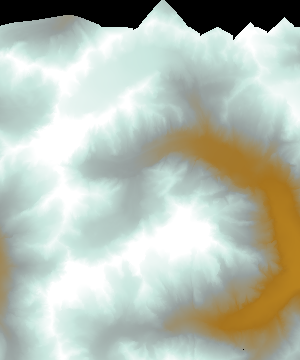

In [97]:
srcglob = datafolder + 'ecrins/*.tif'  #Semis_2021_096*.tif'
Image(S.relief_tiny(srcglob, res=30))

gdalwarp -overwrite -multi -wo NUM_THREADS=ALL_CPUS  -tr 30 -30 ../../mapdata/lidarhd_data/mer-de-glace/*.tif /tmp/tiny.tif
Creating output file that is 400P x 400L.
Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif [1/125] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif to destination /tmp/tiny.tif.
..Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6536_LA93_IGN69_50CM_TIN.tif [2/125] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6536_LA93_IGN69_50CM_TIN.tif.
Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6537_LA93_IGN69_50CM_TIN.tif [3/125] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/mer-de-gl

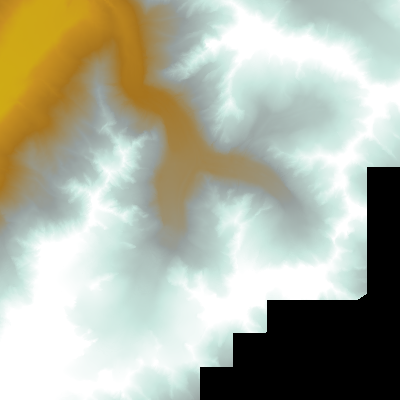

In [104]:
srcglob = datafolder + 'mer-de-glace/*.tif'  #Semis_2021_096*.tif'
Image(S.relief_tiny(srcglob, res=30))

gdalwarp -overwrite -multi -wo NUM_THREADS=ALL_CPUS  -tr 30 -30 ../../mapdata/lidarhd_data/*.tif /tmp/tiny.tif
Creating output file that is 433P x 500L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif [1/195] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/tiny.tif.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6440_LA93_IGN69_50CM_TIN.tif [2/195] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6440_LA93_IGN69_50CM_TIN.tif.
.Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6441_LA93_IGN69_50CM_TIN.tif [3/195] : Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6441_LA93_IGN69_50CM_TIN.tif.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6

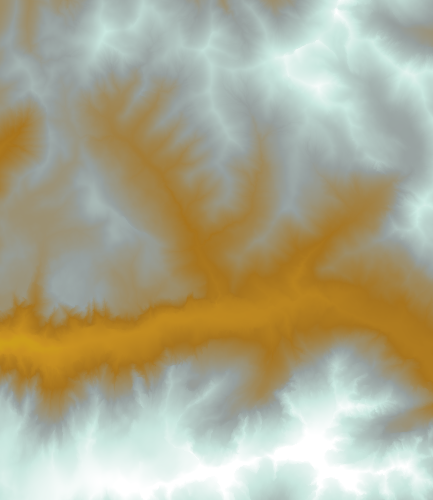

In [96]:
Image(S.relief_tiny(srcglob, res=30))

gdalwarp -overwrite -tr 30 -30 ../../mapdata/lidarhd_data/*.tif /tmp/tiny.tif
Creating output file that is 433P x 500L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif [1/195] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/tiny.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6440_LA93_IGN69_50CM_TIN.tif [2/195] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6440_LA93_IGN69_50CM_TIN.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6441_LA93_IGN69_50CM_TIN.tif [3/195] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_09

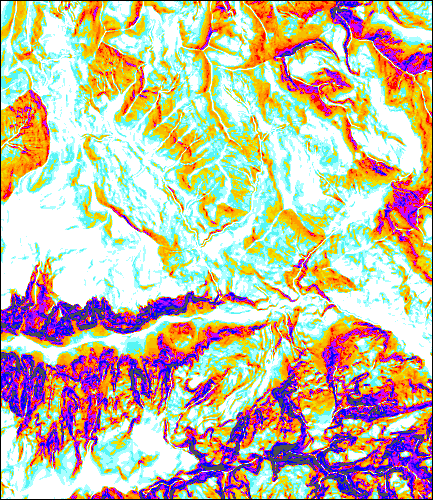

In [95]:
Image(S.eslo_tiny(srcglob, res=30))

In [156]:
NC = {
    'aig_salvador': '0962_6452',
    'aig_argentiere_nw': '0963_6452',
    'aig_argentiere_n': '0964_6452',
    'aig_argentiere': '0964_6451',
    'aig_goleon': '0961_6451',
    'trois_eveches_n': '0964_6448',
    'trois_eveches': '0964_6447',

    'girose': '0957_6439',
    'rateau': '0958_6439',
    'meije': '0960_6440',
    'gaspard': '0962_6439',
    'meije_orient': '0961_6440',
    'grave_ruillans': '0957_6440',
    'grave_chancel': '0957_6442',
    'grave_freaux': '0957_6443',
}

In [135]:
name = 'trois_eveches_n'
coord = NC[name]
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [136]:
name = 'trois_eveches'
coord = NC[name]
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [ ]:
name = 'aig_goleon'
coord = NC[name]
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [ ]:
name, coord = 'aig_argentiere', '0964_6451'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [125]:
name, coord = 'aig_argentiere_n', '0964_6452'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [126]:
name, coord = 'aig_argentiere_nw', '0963_6452'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [127]:
name, coord = 'aig_salvador', '0962_6452'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [ ]:
name, coord = 'girose', '0957_6439'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [86]:
# downsample by half
!gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_1m.tif
!gdaldem slope /tmp/{name}_1m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_1m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_1m_eslo13near.png -filter point -resize 200% /tmp/{name}_1m_eslo13near2x.png
!rm /tmp/{name}_1m_eslo13near.png  /tmp/{name}.tif /tmp/{name}_1m.tif

Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/girose_1m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [98]:
# downsample by 3x
!gdalwarp -tr 1.5 1.5 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_1m5.tif
!gdaldem slope /tmp/{name}_1m5.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_1m5_eslo13near.png -nearest_color_entry
#zoom result by 3x
!magick convert /tmp/{name}_1m5_eslo13near.png -filter point -resize 300% /tmp/{name}_1m5_eslo13near3x.png
!rm /tmp/{name}_1m5_eslo13near.png  /tmp/{name}.tif /tmp/{name}_1m5.tif

Creating output file that is 667P x 667L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/girose_1m5.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [87]:
# downsample by 4x
!gdalwarp -tr 2 2 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_2m.tif
!gdaldem slope /tmp/{name}_2m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_2m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_2m_eslo13near.png -filter point -resize 400% /tmp/{name}_2m_eslo13near4x.png
!rm /tmp/{name}_2m_eslo13near.png /tmp/{name}.tif /tmp/{name}_2m.tif

Creating output file that is 500P x 500L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0957_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/girose_2m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [88]:
name, coord = 'rateau', '0958_6439'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [89]:
# downsample by half
!gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_1m.tif
!gdaldem slope /tmp/{name}_1m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_1m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_1m_eslo13near.png -filter point -resize 200% /tmp/{name}_1m_eslo13near2x.png
!rm /tmp/{name}_1m_eslo13near.png  /tmp/{name}.tif /tmp/{name}_1m.tif

Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/rateau_1m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [92]:
# downsample by 3x
!gdalwarp -tr 1.5 1.5 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_1m5.tif
!gdaldem slope /tmp/{name}_1m5.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_1m5_eslo13near.png -nearest_color_entry
#zoom result by 3x
!magick convert /tmp/{name}_1m5_eslo13near.png -filter point -resize 300% /tmp/{name}_1m5_eslo13near3x.png
!rm /tmp/{name}_1m5_eslo13near.png  /tmp/{name}.tif /tmp/{name}_1m5.tif

Creating output file that is 667P x 667L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/rateau_1m5.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [90]:
# downsample by 4x
!gdalwarp -tr 2 2 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_2m.tif
!gdaldem slope /tmp/{name}_2m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_2m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_2m_eslo13near.png -filter point -resize 400% /tmp/{name}_2m_eslo13near4x.png
!rm /tmp/{name}_2m_eslo13near.png /tmp/{name}.tif /tmp/{name}_2m.tif

Creating output file that is 500P x 500L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0958_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/rateau_2m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [93]:
name, coord = 'meije', '0960_6440'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [78]:
name, coord = 'meijeorient', '0961_6440'
!gdaldem slope ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_0m5_eslo13near.png -nearest_color_entry

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [79]:
# downsample by half
!gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_1m.tif
!gdaldem slope /tmp/{name}_1m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_1m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_1m_eslo13near.png -filter point -resize 200% /tmp/{name}_1m_eslo13near2x.png
!rm /tmp/{name}_1m_eslo13near.png /tmp/{name}.tif /tmp/{name}_1m.tif

Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif to destination /tmp/meijeorient_1m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [80]:
# downsample by 4x
!gdalwarp -tr 2 2 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS ../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif /tmp/{name}_2m.tif
!gdaldem slope /tmp/{name}_2m.tif -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS /tmp/{name}.tif
!gdaldem color-relief /tmp/{name}.tif ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr /tmp/{name}_2m_eslo13near.png -nearest_color_entry
#zoom result by 2x
!magick convert /tmp/{name}_2m_eslo13near.png -filter point -resize 400% /tmp/{name}_2m_eslo13near4x.png
!rm /tmp/{name}_2m_eslo13near.png /tmp/{name}.tif /tmp/{name}_2m.tif

Creating output file that is 500P x 500L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0961_6440_LA93_IGN69_50CM_TIN.tif to destination /tmp/meijeorient_2m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [137]:
def sample(name, coord, res, mode='nearest',
        default_opt=S.DFLT_OPT):
    coord = coord or NC[name]
    ress = f'{int(res)}m{int((res*10) % 10)}'
    resmodecmd = '' if res == 0.5 else f'-tr {res} {res} -r {mode}'
    modesort = 'a' if mode == 'nearest' else 'z' if mode == 'bilinear' else ''
    zoom = int(res * 2)
    zoompct = int(100 * res * 2)
    src = f'../../mapdata/lidarhd_data/Semis_2021_{coord}_LA93_IGN69_50CM_TIN.tif'
    folder = './tmp'
    prefix = f'{folder}/{name}_{ress}_{modesort}{mode}'
    if not os.path.exists(folder): os.mkdir(folder)
    dest1 = f'{prefix}.tif' if res != 0.5 else src
    dest2 = f'{prefix}_slope.tif'
    dest3 = f'{prefix}_eslo13near.png'
    dest4 = f'{prefix}_eslo13near_{zoom}x.png'
    if os.path.exists(dest4):
        print(f'{dest4} already exists')
        return
    if res != 0.5:
        S.check_run(printed(f'gdalwarp {resmodecmd} {default_opt}  -overwrite {src} {dest1}'))
    S.check_run(f'        gdaldem slope {dest1} {default_opt} {dest2}')
    S.check_run(f'        gdaldem color-relief {dest2} ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr {dest3} -nearest_color_entry')
    S.check_run(printed(f'magick convert {dest3} -filter point -resize {zoompct}% {dest4}'))
    S.check_run(f'        rm {dest1 if dest1 != src else ""} {dest2} {dest3}')

for setup in [(0.5, 'nearest'),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('girose', '0957_6439', *setup)

./tmp/girose_0m5_anearest_eslo13near_1x.png already exists
./tmp/girose_1m0_average_eslo13near_2x.png already exists
./tmp/girose_1m0_anearest_eslo13near_2x.png already exists
./tmp/girose_1m0_zbilinear_eslo13near_2x.png already exists
./tmp/girose_1m5_average_eslo13near_3x.png already exists
./tmp/girose_1m5_anearest_eslo13near_3x.png already exists
./tmp/girose_1m5_zbilinear_eslo13near_3x.png already exists
./tmp/girose_2m0_average_eslo13near_4x.png already exists
./tmp/girose_2m0_anearest_eslo13near_4x.png already exists


In [138]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('meije', '', *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/meije_0m5__eslo13near.png -filter point -resize 100% ./tmp/meije_0m5__eslo13near_1x.png
./tmp/meije_1m0_average_eslo13near_2x.png already exists
./tmp/meije_1m0_anearest_eslo13near_2x.png already exists
./tmp/meije_1m0_zbilinear_eslo13near_2x.png already exists
./tmp/meije_1m5_average_eslo13near_3x.png already exists
./tmp/meije_1m5_anearest_eslo13near_3x.png already exists
./tmp/meije_1m5_zbilinear_eslo13near_3x.png already exists
./tmp/meije_2m0_average_eslo13near_4x.png already exists
./tmp/meije_2m0_anearest_eslo13near_4x.png already exists


In [ ]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('meije_orient', '0961_6440', *setup)

In [119]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('meije_savon_aigle', '0961_6441', *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/meije_savon_0m5_anearest_eslo13near.png -filter point -resize 100% ./tmp/meije_savon_0m5_anearest_eslo13near_1x.png
gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS   -overwrite ../../mapdata/lidarhd_data/Semis_2021_0961_6441_LA93_IGN69_50CM_TIN.tif ./tmp/meije_savon_1m0_average.tif
Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0961_6441_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0961_6441_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0961_6441_LA93_IGN69_50CM_TIN.tif to destination ./tmp/meije_savon_1m0_average.tif.
...10...20..

In [121]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    # sample('grave_ruillans', '0957_6440', *setup)
    sample('grave_chancel', '0957_6442', *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/grave_chancel_0m5__eslo13near.png -filter point -resize 100% ./tmp/grave_chancel_0m5__eslo13near_1x.png
gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS   -overwrite ../../mapdata/lidarhd_data/Semis_2021_0957_6442_LA93_IGN69_50CM_TIN.tif ./tmp/grave_chancel_1m0_average.tif
Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0957_6442_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0957_6442_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0957_6442_LA93_IGN69_50CM_TIN.tif to destination ./tmp/grave_chancel_1m0_average.tif.
...10...20...30...40

In [122]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('grave_freaux', '0957_6443', *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/grave_freaux_0m5__eslo13near.png -filter point -resize 100% ./tmp/grave_freaux_0m5__eslo13near_1x.png
gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS   -overwrite ../../mapdata/lidarhd_data/Semis_2021_0957_6443_LA93_IGN69_50CM_TIN.tif ./tmp/grave_freaux_1m0_average.tif
Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0957_6443_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0957_6443_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0957_6443_LA93_IGN69_50CM_TIN.tif to destination ./tmp/grave_freaux_1m0_average.tif.
...10...20...30...40...5

In [157]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    sample('gaspard', NC['gaspard'], *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/gaspard_0m5__eslo13near.png -filter point -resize 100% ./tmp/gaspard_0m5__eslo13near_1x.png
gdalwarp -tr 1 1 -r average -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS   -overwrite ../../mapdata/lidarhd_data/Semis_2021_0962_6439_LA93_IGN69_50CM_TIN.tif ./tmp/gaspard_1m0_average.tif
Creating output file that is 1000P x 1000L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0962_6439_LA93_IGN69_50CM_TIN.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0962_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0962_6439_LA93_IGN69_50CM_TIN.tif to destination ./tmp/gaspard_1m0_average.tif.
...10...20...30...40...50...60...70...80...9

In [140]:
for setup in [(0.5, ''),
              (1, 'average'), (1, 'nearest'), (1, 'bilinear'),
              (1.5, 'average'), (1.5, 'nearest'), (1.5, 'bilinear'),
              (2, 'average'), (2, 'nearest')]:
    for name in ['trois_eveches', 'trois_eveches_n', 'aig_goleon', 'aig_argentiere', 'aig_argentiere_n', 'aig_argentiere_nw', 'aig_salvador', 'gaspard']:
        sample(name, '', *setup)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/trois_eveches_0m5__eslo13near.png -filter point -resize 100% ./tmp/trois_eveches_0m5__eslo13near_1x.png
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/trois_eveches_n_0m5__eslo13near.png -filter point -resize 100% ./tmp/trois_eveches_n_0m5__eslo13near_1x.png
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/aig_goleon_0m5__eslo13near.png -filter point -resize 100% ./tmp/aig_goleon_0m5__eslo13near_1x.png
0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.
magick convert ./tmp/aig_argentiere_0m5__eslo13near.png -filter point -resize 100% ./tmp/aig_argentiere_0m5__eslo13near_1x.png
0...10...20.

gdalwarp -overwrite -tr 8 -8 ../../mapdata/lidarhd_data/*_6439_LA*.tif ../../mapdata/lidarhd_data/*_6440_LA*.tif /tmp/tiny.tif
Creating output file that is 1375P x 250L.
Processing ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif [1/22] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/Semis_2021_0952_6439_LA93_IGN69_50CM_TIN.tif to destination /tmp/tiny.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/Semis_2021_0953_6439_LA93_IGN69_50CM_TIN.tif [2/22] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/Semis_2021_0953_6439_LA93_IGN69_50CM_TIN.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/Semis_2021_0954_6439_LA93_IGN69_50CM_TIN.tif [3/22] : 0Using internal nodata values (e.g. -9999) for

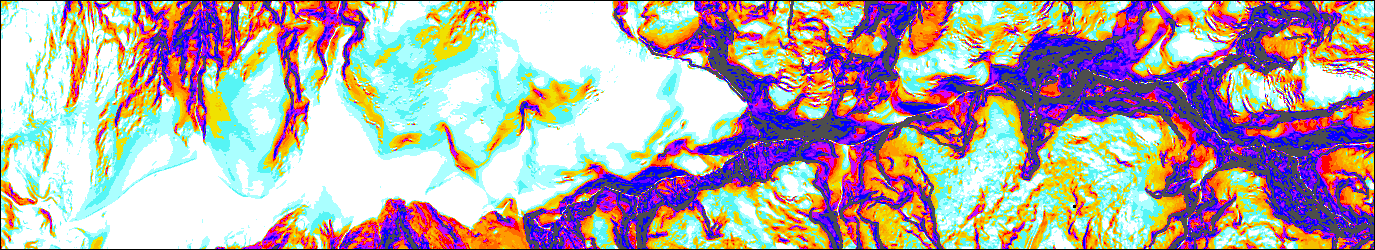

In [45]:
srcglobmeije = datafolder + '*_6439_LA*.tif ' + datafolder + '*_6440_LA*.tif'
Image(S.eslo_tiny(srcglobmeije, res=8))

In [35]:
!ls $S.CMAPDIR

aosta-dtm0508-urls.txt		     gdaldem-slope-eslo14near.clr
colormap-cslo.png		     gdaldem-slope-eslo4near.clr
colormap-eslo14near.png		     gdaldem-slope-greyscale.clr
colormap-eslo4near.png		     gdaldem-slope-hslo1.clr
colormap-hslo1.png		     gdaldem-slope-hslo2.clr
colormap-hslo2.png		     gdaldem-slope-hslo.clr
colormap-oslo8near.png		     gdaldem-slope-ign.clr
colormap-oslo9.png		     gdaldem-slope-mytempsorbet.clr
colormap-sorbet.png		     gdaldem-slope-oslo8ex.clr
eslope_alps_extents.geojson	     gdaldem-slope-oslo8near.clr
extents-alps.geojson		     gdaldem-slope-oslo9.clr
extents-alps-only-frit-topo.geojson  gdaldem-slope-sorbet.clr
extents-alps-only-regions.geojson    ign-rge-alti-5m-urls.txt
extents-alps-only-tms.geojson	     OpenSlopeMap_Overlay_Style.qml
gdaldem-slope-cslo.clr		     piemonte-all-dtm5-urls.txt
gdaldem-slope-cslo-v2.clr	     piemonte-alpi-dtm5-urls.txt
gdaldem-slope-eslo11near.clr	     slope_local
gdaldem-slope-eslo13near.clr	     swiss_cantons.topojson


* At 2m many small features (crevasses...) are lost ; but it's the first one where lidar artifacts (see col de la girose) are significantly smoothed out 
* "Cubic" produces artifacts eg at the foot of cliffs, otherwise close to averag
* whereas "bilinear" produces good balance: smoother while keeping features like couloirs.
-> Choose between 1m average <> 1m bilinear <> 1m5 bilinear

bilinear has my pref ; 1m5 is enoigh for not too much pollution

# Pipeline

In [21]:
%cd ..

/home/eoubrayrie/mapproj/eslope/development


In [22]:
%pwd

'/home/eoubrayrie/mapproj/eslope/development'

In [119]:
name, BB = 'AlpsW', bbox.bbwalps
name, BB = 'meije', S.BBox(6.20, 44.99, 6.37, 45.13).snap_to_xyz(z=13)
name, BB = 'ecrins', S.BBox(6.33, 44.866, 6.452, 44.96).snap_to_xyz(z=13)
name, BB = 'mer-de-glace', S.BBox(6.86, 45.83, 7.04, 45.956).snap_to_xyz(z=13, mode='~')
print(BB)
src = f'../../mapdata/lidarhd_data/{name}/*.tif'

TR = 1.5  # the downsampled resolution of lambert93 dtm *before* slope and WGS reprojection
#          1.5 strikes a good balances between detail and readability of resulting z16 tiles.
prefix = f'./tmp/{name}_1m5_' if TR == 1.5 else f'./tmp/{name}_0m5_' if TR == 0.5 else f'./tmp/{name}_{TR}m_'
dest1 = prefix + 'dtm.tif'
dest2 = prefix + 'slope.tif'
dest3 = prefix + 'eslo.mbtiles'
# dest4 = prefix + 'mbtiles'

print(src, dest1, dest3)

6.855469 45.828799 7.031250 45.951150
../../mapdata/lidarhd_data/mer-de-glace/*.tif ./tmp/mer-de-glace_1m5_dtm.tif ./tmp/mer-de-glace_1m5_eslo.mbtiles


In [120]:
S.check_run(printed(f'gdalwarp -tr {TR} {TR} -r bilinear {S.DFLT_OPT} -overwrite {src} {dest1}'))
S.check_run(printed(f'gdaldem slope {dest1} {S.DFLT_OPT} {dest2}'))

gdalwarp -tr 1.5 1.5 -r bilinear -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS  -overwrite ../../mapdata/lidarhd_data/mer-de-glace/*.tif ./tmp/mer-de-glace_1m5_dtm.tif


Creating output file that is 8000P x 8000L.
Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif [1/125] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif.
Copying nodata values from source ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6535_LA93_IGN69_50CM_TIN.tif to destination ./tmp/mer-de-glace_1m5_dtm.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6536_LA93_IGN69_50CM_TIN.tif [2/125] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6536_LA93_IGN69_50CM_TIN.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
Processing ../../mapdata/lidarhd_data/mer-de-glace/Semis_2021_1000_6537_LA93_IGN69_50CM_TIN.tif [3/125] : 0Using internal nodata values (e.g. -9999) for image ../../mapdata/lidarhd

0

In [121]:
SLOP_CX = prefix + 'slope'

In [122]:
for z in (15, 16):
    S.warp_slopes(src=dest2, dest=f'{SLOP_CX}_z{z}.tif', z=z, extent=f'-te {BB}')

      gdalwarp -ot Byte \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite  \
        -t_srs EPSG:3857 -tr 4.777314267823516 -4.777314267823516 -r q3 \
        -te_srs WGS84 -te 6.855469 45.828799 7.031250 45.951150  -dstnodata 255  \
        ./tmp/mer-de-glace_1m5_slope.tif ./tmp/mer-de-glace_1m5_slope_z15.tif
Creating output file that is 4096P x 4096L.
Processing ./tmp/mer-de-glace_1m5_slope.tif [1/1] : 0Using internal nodata values (e.g. -9999) for image ./tmp/mer-de-glace_1m5_slope.tif.
...10...20...30...40...50...60...70..      gdalwarp -ot Byte \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite  \
        -t_srs EPSG:3857 -tr 2.388657133911758 -2.38865

In [123]:
R_DSP = 'q3' # tried q1, med
for z in 14, 13, 12, 11:
    S.make_ovr(src=f'{SLOP_CX}_z{z+2}.tif', dest=f'{SLOP_CX}_z{z}.tif', r=R_DSP, z=z, reuse=False)

      gdalwarp -r q3 -tr 9.554628535647032 -9.554628535647032 \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite   \
        ./tmp/mer-de-glace_1m5_slope_z16.tif ./tmp/mer-de-glace_1m5_slope_z14.tif
Creating output file that is 2048P x 2048L.
Processing ./tmp/mer-de-glace_1m5_slope_z16.tif [1/1] : 0Using internal nodata values (e.g. 255) for image ./tmp/mer-de-glace_1m5_slope_z16.tif.
Copying nodata values from source ./tmp/mer-de-glace_1m5_slope_z16.tif to destination ./tmp/mer-de-glace_1m5_slope_z14.tif.
...10...20...30...40...50      gdalwarp -r q3 -tr 19.10925707129406 -19.10925707129406 \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite   \
        ./tm

In [ ]:
# S.eslo_tiny(prefix+'eslo13near_z16.mbtiles', cname='eslo13bnear', res=300, where='./tmp')

In [29]:
from time import time

# Building overviews

Overviews do not need highest quality which is whay I use a combination of downsampling more than necessary then upsampling again.

A z13 and z15 there is a 2x upsampling ; a z14 a 4x upsampling. The algrithms where chosen as follows:

for resampling, be careful as standard comparisons like [these ones](https://superuser.com/questions/375718/which-resize-algorithm-to-choose-for-videos) don't seem representative of what happens when upsampling with gdal.

More relevant is [this SO about DEM](https://gis.stackexchange.com/questions/267433/pros-and-cons-of-using-bilinear-interpolation-and-cubic-convolution-when-dealing) bilinear is good for DEMs (here)
but here I'm working with the slopes, and highest precision is less important than readability of result anyway.

## Downsampling

it is quite important to "round up" slopes when downsampling, to avoid giving the impresion that some routes are feasible.

this example shows the quite narrow cliffs of Pointe Salvador (massif des Aiguilles d'Arves, french alps)

on the right is the source slope data (z16) rendered with palette eslo13b
on the left is the result of twice 4x downsampling (to z12) then  then 4x bilinear upsampling (to z14)
Compared are 3 algos for the downsampling steps, quantiles: q1 / median / q3

it is clear that all but q3 give the false impression that the cliff can be walked down:

![](../img/overviews_downsampling_algos_pointe_salvador.png)

## Upsampling

For building overviews I've compared a few techniques:


* O: "original": build directly from a slope model at the same resolution (downsampled with "q3" algo from zoom+2, recursively)
* First downsample by an additional 4x again with q3, then upsample with various algorithms:\
Average, Bilinear, Cubic, Lanczos (Average is not better than nearest for some reason with gdal)

![](../img/overviews_upsampling_algos_meije.png)

The results favour bilinear again for the readability of the output.


In [124]:
files=[]
R_USP = 'bilinear'
for z, cname in {
        16: 'eslo13bnear',
        15: 'eslo13bnear',
        14: 'eslo4lnear',
        13: 'eslo4lnear',  # TBD oslo3near
        # 12: 'eslo2',
    }.items():
        chkpoint = time()
        slope = f'{SLOP_CX}_z{z}.tif' if z < 15 else f'{SLOP_CX}_z{z}.tif'
        zsrc = {16:16, 15: 14, 14: 12, 13:12}[z]  # would need changes to select target res
        if zsrc != z:
            upsampled = f'{SLOP_CX}_z{zsrc}_up_z{z}.tif'
            S.make_ovr(src=f'{SLOP_CX}_z{zsrc}.tif', dest=upsampled, z=z, r=R_USP, reuse=False)
            slope = upsampled
        # to_merge = S.slope_mbt(cname, z=z, src=f'{SLOP_CX}_z{zsrc}.tif', dest=f'{prefix}{cname}_z{z}.mbtiles',
        #                        options=f'-co ZOOM_LEVEL={z} -co RESAMPLING=nearest', reuse=False)
        to_merge = S.slope_mbt(cname, z=z, src=slope, dest=f'{prefix}{cname}_z{z}_{R_USP}_{R_DSP}.mbtiles', reuse=False)
        files.append(os.path.expanduser(to_merge))  # f'{cname}-z{z}.mbtiles')
        print(f'Zoom {z} completed in {round(time()-chkpoint,1)} seconds')
# S.mbt_merge(*files, dest=f'alpsc/AlpsW_eslo.mbtiles')
S.mbt_merge(*files, dest=f'{prefix}eslo_{R_USP}_{R_DSP}_4l.mbtiles')

sed 's/nv \+0 \+0 \+0/nv  255 255 255/g' '/home/eoubrayrie/mapproj/eslope/development/data/gdaldem-slope-eslo13bnear.clr' 
\
      gdaldem color-relief ./tmp/mer-de-glace_1m5_slope_z16.tif /tmp/gdaldem-slope-eslo13bnear.clr ./tmp/mer-de-glace_1m5_eslo13bnear_z16_bilinear_q3.mbtiles \
          -nearest_color_entry -co TILE_FORMAT=png8 
0...10...20...30...40...50...60...70...80...90...100 - done.
Zoom 16 completed in 5.3 seconds
      gdalwarp -r bilinear -tr 4.777314267823516 -4.777314267823516 \
        -co COMPRESS=ZSTD -co PREDICTOR=2 -co ZSTD_LEVEL=3 -co TILED=YES -co blockXsize=1024 -co blockYsize=1024 -co BIGTIFF=YES -co SPARSE_OK=TRUE -co NUM_THREADS=ALL_CPUS -multi -wo NUM_THREADS=ALL_CPUS -overwrite   \
        ./tmp/mer-de-glace_1m5_slope_z14.tif ./tmp/mer-de-glace_1m5_slope_z14_up_z15.tif
Creating output file that is 4096P x 4096L.
Processing ./tmp/mer-de-glace_1m5_slope_z14.tif [1/1] : 0Using internal nodata values (e.g. 255) for image ./tmp/mer-de-glace_1m5_slope_z14.tif.


In [161]:
# from src import mbt_util as M
# M.cut_to_lnglat(f'./tmp/AlpsW_eslo.mbtiles', bb=BB.to_llbb(), dest=f'./tmp/AlpsW_eslo_cut.mbtiles')

Backing up dest as: ./tmp/AlpsW_eslo_cut.bak.mbtiles
zoom = 15 16 ; n = 368640 * 0 kb/tile ; bounds = 5.625,43.58039,7.73437,46.55886 ; center = 6.67969,45.06963,15 ; format = png ; name = ./tmp/AlpsW_eslo
cut_to_lnglat ./tmp/AlpsW_eslo.mbtiles -> ./tmp/AlpsW_eslo_cut.mbtiles
15 16 16
z 15: +304 tiles: 16948<x<16963 20979<y<20997
z 16: +1147 tiles: 33897<x<33927 41958<y<41994
Meta update {'bounds': '6.19629,44.98811,6.37207,45.13556',
 'center': '6.28418,45.06183,15',
 'maxzoom': 16,
 'minzoom': 15,
 'type': 'baselayer'}


In [94]:
from src import mbt_util as M
M.cut_to_lnglat(f'/home/eoubrayrie/mapproj/slope-ign-alti/alpsc/esloAlpsW.mbtiles', bb=BB.to_llbb(), dest=f'./tmp/meije_eslo_oldlowres.mbtiles')

zoom = 9 16 ; n = 391698 * 6 kb/tile ; bounds = 5.625,43.58039,6.32813,45.08904 ; center = 5.97656,44.33471,9 ; format = png ; name = alps/esloAlpsW
cut_to_lnglat /home/eoubrayrie/mapproj/slope-ign-alti/alpsc/esloAlpsW.mbtiles -> ./tmp/meije_eslo_oldlowres.mbtiles
9 16 16
z 9: +4 tiles: 264<x<265 327<y<328
z10: no tiles, skipping
z11: no tiles, skipping
z12: no tiles, skipping
z 13: +24 tiles: 4237<x<4240 5244<y<5249
z 14: +80 tiles: 8474<x<8481 10489<y<10498
z 15: +304 tiles: 16948<x<16963 20979<y<20997
z 16: +1147 tiles: 33897<x<33927 41958<y<41994
Meta update {'bounds': '5.625,44.59047,7.03125,45.58329',
 'center': '6.32813,45.08688,9',
 'maxzoom': 16,
 'minzoom': 9,
 'type': 'baselayer'}


In [ ]:
S.check_run(printed(f'gdaldem color-relief {dest2} ~/mapproj/eslope/development/data/gdaldem-slope-eslo13near.clr {dest3} -nearest_color_entry'))

### Status 112024/01/28

* Keeping with 1m5 bilinear as even 1m bilinear brings too much extra detail (a bit more couloir/crevasse detail at the expense of overall readability) -- end-to-end example comparison in file 'eslo dtm resampling comparison 1m-b vs 1m5-b over meije.jpg'
* Tried a ligher hue for eslo4near, but results are underwhelming, TODO just keep lighter grey
* Ready to reintegrate meije in a proper esloAlpsW pipeline with the new colors!


### There will be a x3 inxcrease in size for the french side of esloAlpsW (60% of it) → x2 in total
so ~ 5 GB in total. cuttng in 3 would be necessary (TBD at the very end of the mbtiles)